## Knn regressor

#### Imports

In [141]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from skopt import BayesSearchCV
import scipy.stats as stats

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Utility function

In [142]:
def regression_report(predicted, true):
    mean_squared_error_value = mean_squared_error(true, predicted)
    mean_absolute_error_value = mean_absolute_error(true, predicted)
    r2_score_value = r2_score(true, predicted)
    root_mean_squared_error_value = root_mean_squared_error(true, predicted)

    print("="*50)
    print("       Regression performance report" )
    print("="*50)
    print(
    "   Mean squared error: ",  np.round(mean_squared_error_value, 3), "\n"
    "   Mean absolute error:",  np.round(mean_absolute_error_value, 3), "\n"
    "   Root mean squared error:",             np.round(root_mean_squared_error_value, 3), "\n"
    "   R2 score:",             np.round(r2_score_value, 3)
    )
    print("="*50)


In [143]:
def plot_actual_predicted(true, predicted):
    true = np.ravel(true)
    predicted = np.ravel(predicted)

    plt.figure(figsize=(8,6))

    sns.scatterplot(x=true, y=predicted, alpha=0.7, edgecolors='k', label="Predictions")

    min_value, max_value = min(true.min(), predicted.min()), max(true.max(), predicted.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="purple", linestyle='--', label="y = x")

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted values")
    plt.legend()
    plt.grid(True)


In [144]:
def histogram_residuals(true, predicted):
    residuals = true - predicted
    
    
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=10, kde=True, color='blue') 
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.show()

In [146]:
X_train = pd.read_csv("x_train.csv",index_col=0)
y_train = pd.read_csv("y_train.csv" ,index_col=0)

X_test = pd.read_csv("x_test.csv",index_col=0)
y_test = pd.read_csv("y_test.csv",index_col=0)

#### Basic training

In [147]:
knn_regressor = KNeighborsRegressor()
knn_regressor.fit(X_train, y_train)

KNeighborsRegressor()

#### Prediction and accuracy

In [148]:
knn_predict1 = knn_regressor.predict(X_test)

regression_report(knn_predict1, y_test)

       Regression performance report
   Mean squared error:  0.429 
   Mean absolute error: 0.384 
   Root mean squared error: 0.655 
   R2 score: 0.695


#### Visualization of the regression

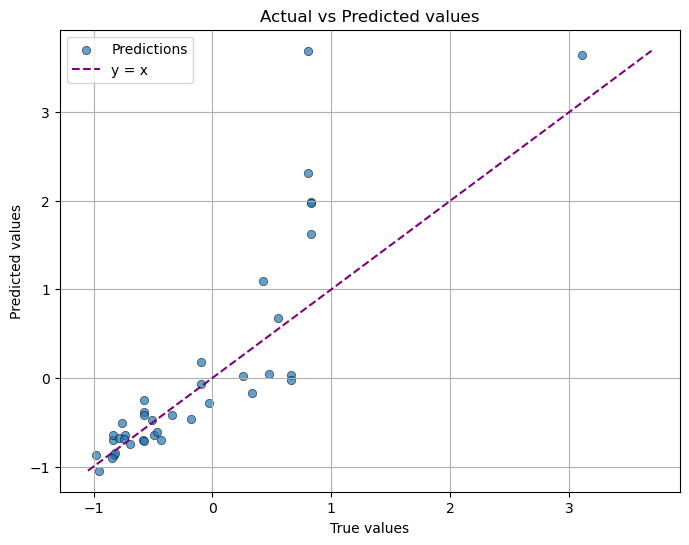

In [149]:
plot_actual_predicted(knn_predict1, y_test)

We notice that the points somehow follow a straight line but there is some deviation.

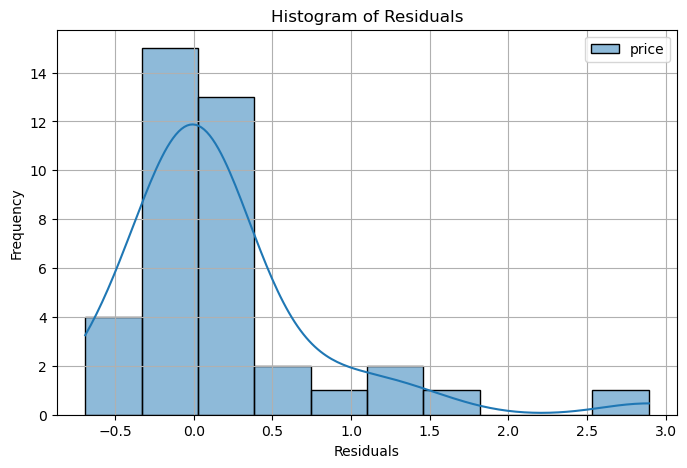

In [150]:
histogram_residuals(y_test, knn_predict1)

 The residuals appear to be positively skewed

#### Let's do some hyperparameter tuning using bayesian search to find the best setup

In [ ]:
from skopt.space import Integer, Categorical

search_space = {
    'n_neighbors': Integer(1, 50),  
    'weights': ['distance'],   #because of the presence of outliers let's choose weighted knn
    'metric': ['euclidean', 'manhattan'], 
}


In [162]:
bayes_search = BayesSearchCV(
    knn_regressor,
    search_space,
    n_iter=20,  
    cv=5,   # 10-fold cross-validation
    scoring='neg_mean_absolute_error',  
    n_jobs=-1,
    random_state=42,
    return_train_score=True
)

bayes_search.fit(X_train, y_train)

print("Best Parameters setup:", bayes_search.best_params_)

c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 42, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(
c:\Users\sara\anaconda3\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point ['manhattan', 1, 'distance'] before, using random point ['euclidean', 7, 'distance']
  warnings.warn(


Best Parameters setup: OrderedDict({'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'})


From this we see that the best parameters are:  
Distance = manhattan    
k = 4   
weights = distance    

Let's build our knn regressor based on this

In [163]:
knn_regressor2 = KNeighborsRegressor(n_neighbors=4, metric="manhattan",weights="distance")
knn_regressor2.fit(X_train, y_train)

KNeighborsRegressor(metric='manhattan', n_neighbors=4, weights='distance')

#### Prediction and report

In [164]:
knn_predict2 = knn_regressor2.predict(X_test)

regression_report(knn_predict2, y_test)

       Regression performance report
   Mean squared error:  0.21 
   Mean absolute error: 0.26 
   Root mean squared error: 0.458 
   R2 score: 0.851


#### Visualization of the regression 

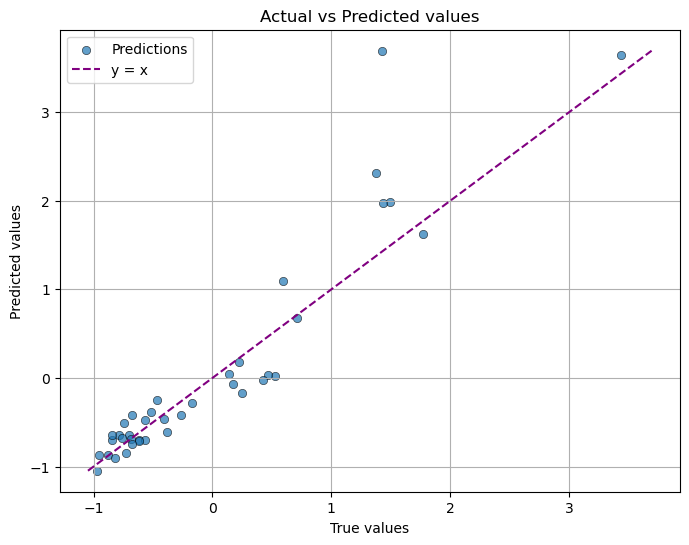

In [165]:
plot_actual_predicted(knn_predict2, y_test)

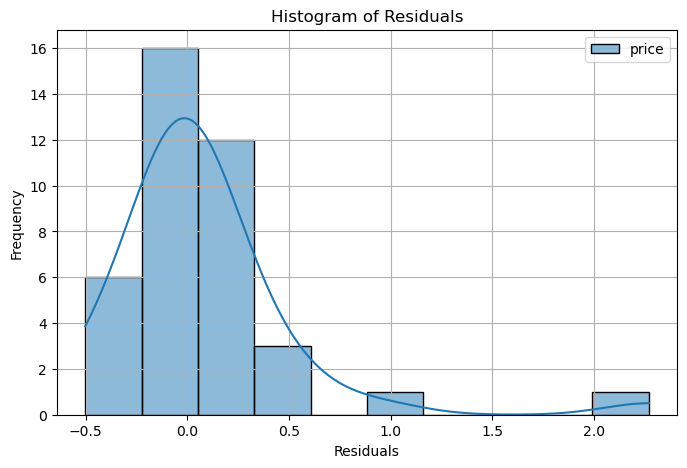

In [166]:
histogram_residuals(y_test, knn_predict2)

 The residuals are still positively skewed

Cross validation

In [169]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer

cv = KFold(n_splits=10, shuffle=True, random_state=42)

# scoring metrics
scoring = {
    'MAE': make_scorer(mean_absolute_error),
    'MSE':make_scorer(mean_squared_error),
    'RMSE':make_scorer(root_mean_squared_error),
    'R2': 'r2'
}

results = cross_validate(knn_regressor2, X_train, y_train, cv=cv, scoring=scoring)

#results
print(f"Test R²: {np.mean(results['test_R2']):.3f} (±{np.std(results['test_R2']):.3f})")
print(f"Test MAE: {np.mean(results['test_MAE']):.3f} (±{np.std(results['test_MAE']):.3f})")
print(f"Test MSE: {np.mean(results['test_MSE']):.3f} (±{np.std(results['test_MSE']):.3f})")
print(f"Test RMSE: {np.mean(results['test_RMSE']):.3f} (±{np.std(results['test_RMSE']):.3f})")



Test R²: 0.832 (±0.118)
Test MAE: 0.229 (±0.059)
Test MSE: 0.122 (±0.086)
Test RMSE: 0.330 (±0.114)


#### Conclusion

The KNN regression model has strong predictive performance with an  R² score of 0.851 and a stable one in the cross validation. 

Cross validation results for the other evaluation metrics confirm that the model is generalizing well since they fall within the expected range.    

The visualization of the result (the scatter plot, histogram of the residuals) indicate that the predictions are reliable but there is a presence of outliers.  

The trial of minimizing the impact of these outliers using knn seems to not be totally efficient which indicates that knn algorithm which is a distance based algorithm is not the most suitable one for this task and this data.